In [244]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import equilibrium_critical_correlations as eq
from common_imports import *

r_max = 100
n_values = [1,2,3,4]
folder = "data/"
tau_filenames = [folder+f"data_Pn_corr_n{n}_rmax{r_max}.npz" for n in n_values]
critical_corr_filenames = [folder+f"critical_correlation_n{n}_rmax{r_max}.npz.npy" for n in n_values]
r= np.load(tau_filenames[0])["r"]
taus = np.load(folder+"data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['taus']
states= np.load(folder+"data_KZ_L500_t0_N100_tau1.0e-03-3.2e+03.npz")['states']

PP_quenched = ([np.load(filename)['PP_corr'] for filename in tau_filenames])
crit = ([np.load(filename) for filename in critical_corr_filenames])
P_quenched= ([np.load(filename)['P'] for filename in tau_filenames])

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_8342/240651743.py:3: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  loglog()
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


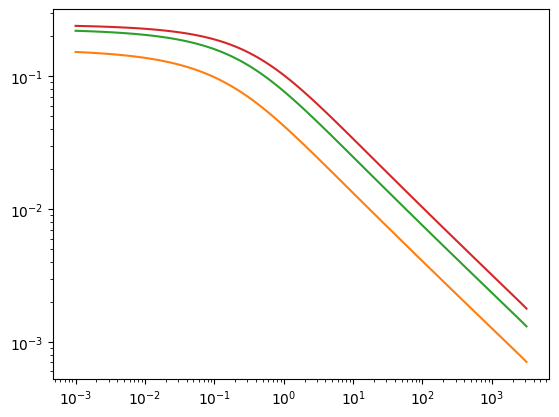

In [259]:
for i in n_values:
    plot(taus,eq.P_n(i)-P_quenched[i-1])
    loglog()

In [236]:
PP_quench_sf = fftshift(fft(PP_quenched, axis=-1), axes=-1)
PP_crit_sf   = fftshift(fft(crit, axis=-1), axes=-1)
k = fftshift(fftfreq(len(r//2),1))*2*pi
rhos = array([eq.sigma_general([0,1])-kz.sigma_general([0,1],s) for s in states])

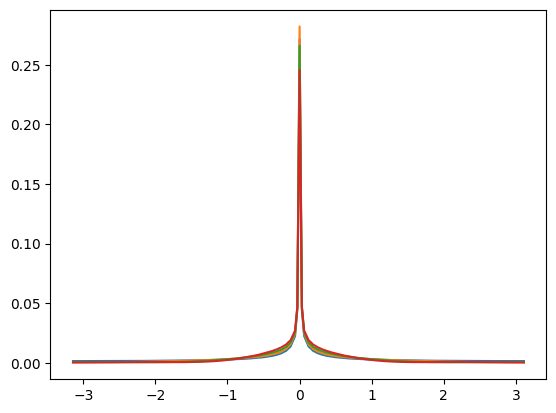

In [243]:
for n in n_values:
    i=n-1
    PP= PP_crit_sf[i]
    plot(k,abs(PP)/sum(abs(PP)))
#loglog()
#xlim(0,100)

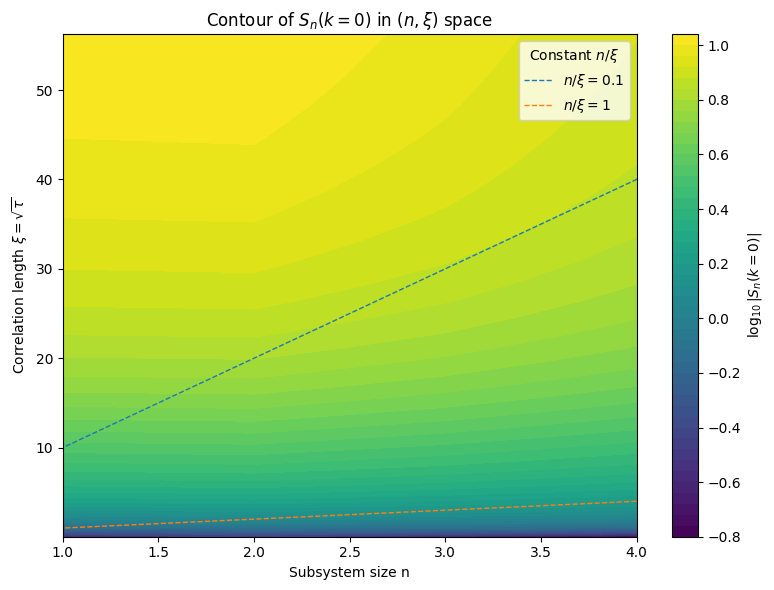

In [204]:
import numpy as np
import matplotlib.pyplot as plt

# correlation length proxy
xi_vals = sqrt(taus)   # b(τ) ≈ ξ

# observable: S(k=0)
S0_vals = np.array([np.abs(PP_quench_sf[n-1, :, 100]) for n in n_values])  # shape (len(n_values), len(taus))

# build grids for contour
N, Xi = np.meshgrid(n_values, xi_vals)   # shape (len(taus), len(n_values))
Z = np.log10(S0_vals.T)                  # transpose so τ (ξ) varies vertically, n horizontally

# --- contour plot ---
plt.figure(figsize=(8,6))
contour = plt.contourf(N, Xi, Z, levels=50, cmap="viridis")
cbar = plt.colorbar(contour)
cbar.set_label(r"$\log_{10}|S_n(k{=}0)|$")

# overlay lines of constant n/ξ
ratios = [0.1,1]
for r in ratios:
    xi_line = np.linspace(np.min(xi_vals), np.max(xi_vals), 200)
    plt.plot(r*xi_line, xi_line, "--", lw=1, label=f"$n/\\xi={r}$")

# --- labels and scales ---
plt.xlabel("Subsystem size n")
plt.ylabel(r"Correlation length $\xi = \sqrt{\tau}$")
plt.title(r"Contour of $S_n(k{=}0)$ in $(n, \xi)$ space")
plt.legend(title="Constant $n/\\xi$")
#plt.xscale("log")
#plt.yscale("log")
plt.tight_layout()
xlim(1,4)
plt.show()


In [180]:
print(k[100])  # should be 0 or very close


0.0


In [221]:
from numpy.fft import fft, fftshift, fftfreq

k_vals = fftshift(fftfreq(r_max, d=1) * 2 * np.pi)  # momentum grid for r in [0, r_max)
PP_quenched_sf = []

for i, n in enumerate(n_values):
    PP_n = PP_quenched[i]  # shape: (len(taus), len(r))
    sf_n = []
    for corr in PP_n:
        f = fft(corr[:r_max])  # only r = 0..r_max-1
        sf_n.append(np.abs(fftshift(f)))
    PP_quenched_sf.append(np.array(sf_n))

PP_quenched_sf = np.array(PP_quenched_sf)  # shape (n_values, len(taus), r_max)


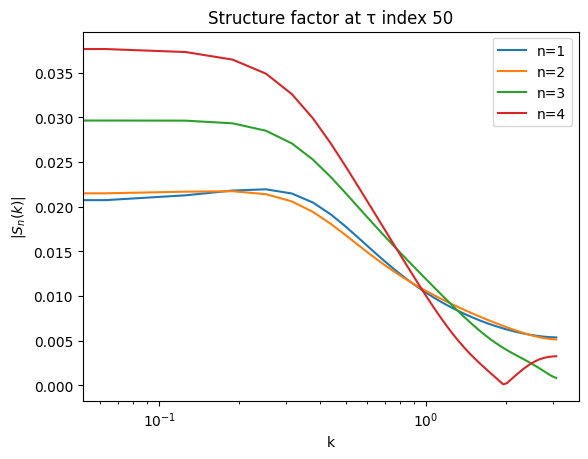

In [234]:
tau_index = 50  # choose index manually
plt.figure()
for i, n in enumerate(n_values):
    plt.plot(k_vals, PP_quenched_sf[i][tau_index]/sum(PP_quenched_sf[i][tau_index]), label=f"n={n}")

plt.xscale("log")
#plt.yscale("log")
plt.xlabel("k")
plt.ylabel(r"$|S_n(k)|$")
plt.legend()
plt.title(f"Structure factor at τ index {tau_index}")
plt.show()
